ResNet is modified to have 5 conv layers, with proressively increasing filter sizes to capture complicated features, normalize after each conv, max pooloing to reduce spetial dims, avg pooling before final classification layer. Data is regularized and optimized with SGD. Additionally, augmentation is increased as initially there's a significant overfitting.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using: {device}")

Using: cuda


In [ ]:
# Stronger augmentation
train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))
])

train_data = datasets.CIFAR10(root='./data', train=True, download=True, transform=train_transform)
test_data = datasets.CIFAR10(root='./data', train=False, download=True, transform=test_transform)

train_loader = DataLoader(train_data, batch_size=128, shuffle=True, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_data, batch_size=128, shuffle=False, num_workers=2, pin_memory=True)


In [ ]:
class ResNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 64, 3, 1, 1)
        self.bn1 = nn.BatchNorm2d(64)

        self.conv2 = nn.Conv2d(64, 128, 3, 1, 1)
        self.bn2 = nn.BatchNorm2d(128)
        self.pool1 = nn.MaxPool2d(2)

        self.conv3 = nn.Conv2d(128, 256, 3, 1, 1)
        self.bn3 = nn.BatchNorm2d(256)

        self.conv4 = nn.Conv2d(256, 256, 3, 1, 1)
        self.bn4 = nn.BatchNorm2d(256)
        self.pool2 = nn.MaxPool2d(2)

        self.conv5 = nn.Conv2d(256, 512, 3, 1, 1)
        self.bn5 = nn.BatchNorm2d(512)

        self.avgpool = nn.AdaptiveAvgPool2d(1)
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(512, 10)

    def forward(self, x):
        x = torch.relu(self.bn1(self.conv1(x)))
        x = self.pool1(torch.relu(self.bn2(self.conv2(x))))
        x = torch.relu(self.bn3(self.conv3(x)))
        x = self.pool2(torch.relu(self.bn4(self.conv4(x))))
        x = torch.relu(self.bn5(self.conv5(x)))
        x = self.avgpool(x)
        x = x.view(x.size(0), -1)
        x = self.dropout(x)
        return self.fc(x)

model = ResNet().to(device)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.SGD(model.parameters(), lr=0.1, momentum=0.9, weight_decay=1e-4)
scheduler = optim.lr_scheduler.MultiStepLR(optimizer, milestones=[25, 40], gamma=0.1)

In [ ]:
def train_epoch(model, loader):
    model.train()
    total_loss, correct, total = 0, 0, 0

    for inputs, labels in loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    return total_loss / len(loader), 100. * correct / total

def evaluate(model, loader):
    model.eval()
    total_loss, correct, total = 0, 0, 0

    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            total_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    return total_loss / len(loader), 100. * correct / total

In [ ]:
# since the data stopped producing significant changes and start somehow oscillating, running is stopped earlier.

num_epochs = 60
best_acc = 0
train_accs=[]
test_accs=[]

train_losses=[]
test_losses=[]

for epoch in range(num_epochs):
    train_loss, train_acc = train_epoch(model, train_loader)
    test_loss, test_acc = evaluate(model, test_loader)
    scheduler.step()

    if test_acc > best_acc:
        best_acc = test_acc
        torch.save(model.state_dict(), 'best_cifar10.pth')
    train_losses.append(train_loss)
    test_losses.append(test_loss)
    train_accs.append(train_acc)
    test_accs.append(test_acc)

    print(f'Epoch {epoch+1}:')
    print(f'Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%')
    print(f'Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.2f}%')


Epoch 1:
Train Loss: 1.7443, Train Acc: 42.66%
Test Loss: 1.7254, Test Acc: 48.87%
Epoch 2:
Train Loss: 1.3896, Train Acc: 60.35%
Test Loss: 1.4196, Test Acc: 62.12%
Epoch 3:
Train Loss: 1.2487, Train Acc: 67.70%
Test Loss: 1.3615, Test Acc: 64.39%
Epoch 4:
Train Loss: 1.1591, Train Acc: 72.39%
Test Loss: 1.1385, Test Acc: 73.63%
Epoch 5:
Train Loss: 1.0968, Train Acc: 75.52%
Test Loss: 1.1120, Test Acc: 76.27%
Epoch 6:
Train Loss: 1.0483, Train Acc: 77.87%
Test Loss: 1.0739, Test Acc: 76.67%
Epoch 7:
Train Loss: 1.0121, Train Acc: 79.79%
Test Loss: 1.0790, Test Acc: 77.71%
Epoch 8:
Train Loss: 0.9825, Train Acc: 81.21%
Test Loss: 1.0112, Test Acc: 80.27%
Epoch 9:
Train Loss: 0.9567, Train Acc: 82.24%
Test Loss: 0.9778, Test Acc: 82.16%
Epoch 10:
Train Loss: 0.9381, Train Acc: 83.24%
Test Loss: 1.0454, Test Acc: 80.70%
Epoch 11:
Train Loss: 0.9160, Train Acc: 84.53%
Test Loss: 1.0040, Test Acc: 80.58%
Epoch 12:
Train Loss: 0.9041, Train Acc: 85.00%
Test Loss: 0.9396, Test Acc: 84.14%
E

KeyboardInterrupt: 

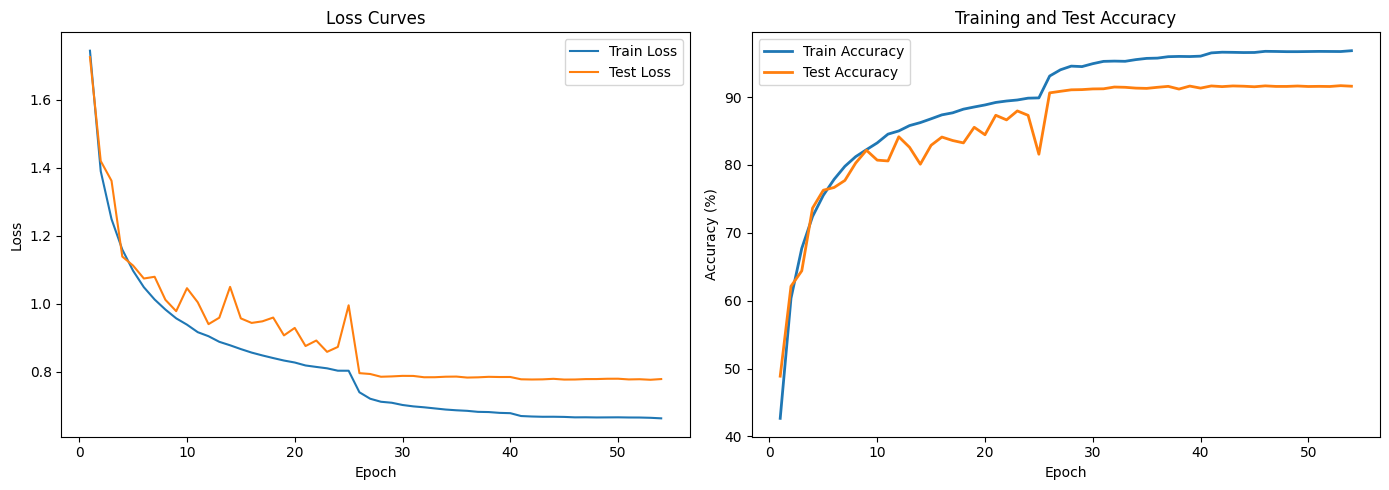

Final Train Accuracy: 96.82%
Final Test Accuracy: 91.59%
Best Test Accuracy: 91.67%


In [ ]:
import matplotlib.pyplot as plt

# Training data
train_losses = [1.7443, 1.3896, 1.2487, 1.1591, 1.0968, 1.0483, 1.0121, 0.9825, 0.9567, 0.9381,
                0.9160, 0.9041, 0.8876, 0.8774, 0.8662, 0.8559, 0.8475, 0.8398, 0.8325, 0.8267,
                0.8180, 0.8137, 0.8096, 0.8026, 0.8025, 0.7391, 0.7201, 0.7112, 0.7083, 0.7017,
                0.6976, 0.6949, 0.6916, 0.6883, 0.6861, 0.6845, 0.6815, 0.6809, 0.6785, 0.6776,
                0.6692, 0.6678, 0.6670, 0.6671, 0.6666, 0.6653, 0.6655, 0.6650, 0.6652, 0.6654,
                0.6649, 0.6648, 0.6640, 0.6624]

train_accs = [42.66, 60.35, 67.70, 72.39, 75.52, 77.87, 79.79, 81.21, 82.24, 83.24,
              84.53, 85.00, 85.79, 86.23, 86.79, 87.37, 87.67, 88.21, 88.53, 88.83,
              89.20, 89.41, 89.56, 89.83, 89.87, 93.09, 94.01, 94.55, 94.48, 94.91,
              95.25, 95.29, 95.26, 95.51, 95.69, 95.73, 95.94, 95.98, 95.96, 96.02,
              96.50, 96.60, 96.58, 96.55, 96.56, 96.73, 96.71, 96.68, 96.68, 96.70,
              96.72, 96.71, 96.70, 96.82]

test_losses = [1.7254, 1.4196, 1.3615, 1.1385, 1.1120, 1.0739, 1.0790, 1.0112, 0.9778, 1.0454,
               1.0040, 0.9396, 0.9586, 1.0493, 0.9565, 0.9432, 0.9479, 0.9590, 0.9065, 0.9285,
               0.8752, 0.8914, 0.8581, 0.8726, 0.9951, 0.7954, 0.7929, 0.7848, 0.7858, 0.7874,
               0.7872, 0.7833, 0.7834, 0.7849, 0.7853, 0.7824, 0.7831, 0.7846, 0.7840, 0.7841,
               0.7773, 0.7767, 0.7771, 0.7787, 0.7765, 0.7767, 0.7779, 0.7780, 0.7789, 0.7790,
               0.7769, 0.7775, 0.7759, 0.7780]

test_accs = [48.87, 62.12, 64.39, 73.63, 76.27, 76.67, 77.71, 80.27, 82.16, 80.70,
             80.58, 84.14, 82.59, 80.10, 82.89, 84.10, 83.59, 83.24, 85.54, 84.44,
             87.31, 86.63, 87.95, 87.30, 81.57, 90.61, 90.84, 91.06, 91.09, 91.19,
             91.21, 91.47, 91.43, 91.31, 91.27, 91.43, 91.57, 91.17, 91.61, 91.31,
             91.63, 91.53, 91.63, 91.59, 91.51, 91.64, 91.56, 91.56, 91.62, 91.55,
             91.57, 91.55, 91.67, 91.59]

epochs = list(range(1, 55))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(epochs, train_losses, label='Train Loss')
ax1.plot(epochs, test_losses, label='Test Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Loss Curves')
ax1.legend()

ax2.plot(epochs, train_accs, label='Train Accuracy', linewidth=2)
ax2.plot(epochs, test_accs, label='Test Accuracy', linewidth=2)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Training and Test Accuracy')
ax2.legend()

plt.tight_layout()
plt.show()

print(f'Final Train Accuracy: {train_accs[-1]:.2f}%')
print(f'Final Test Accuracy: {test_accs[-1]:.2f}%')
print(f'Best Test Accuracy: {max(test_accs):.2f}%')

Initially, it had a proper accuracy but significant overfitting. After adding augmentations, adjusting LR scheduler and batch size, adding label smooting, though there are still sharp turns, they eventually become smooth. A sharp bump around 25 is possibly caused by LR dropping and becomes instable temporarily.